1. Obtenga un modelo de k-means que agrupe observaciones según atributos relacionados con altura, peso y hábitos alimenticios en 7 categorías de sobrepeso (NObeysedad).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("obesity.csv")
df.head()

features = ["Height", "Weight", "FAVC", "FCVC", "NCP", "CAEC", "CH2O", "CALC"]
X = df[features]
X = pd.get_dummies(X, drop_first=True)
X.head()

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=7, random_state=42)
y_kmeans = kmeans.fit_predict(X)


2. Grafique los resultados de clusterización según altura y peso y obtenga el puntaje de evaluación de las estimaciones hechas por k-medias.

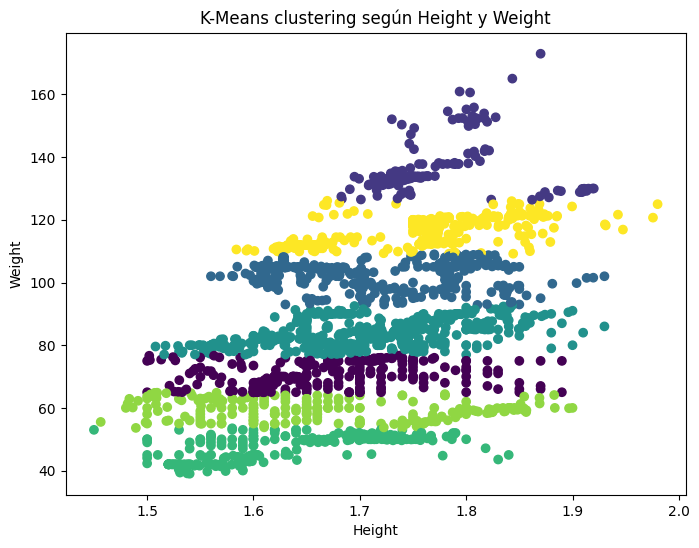

0.5136003470647296

In [2]:
plt.figure(figsize=(8,6))
plt.scatter(df["Height"], df["Weight"], c=y_kmeans)
plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("K-Means clustering según Height y Weight")
plt.show()

from sklearn.metrics import silhouette_score
silhouette_kmeans = silhouette_score(X, y_kmeans)
silhouette_kmeans

3. Aplique las técnicas de reducción de dimensionalidad vistas en la lección al set de datos en análisis para que este sea ahora de dos dimensiones. Genere la visualización correspondiente.

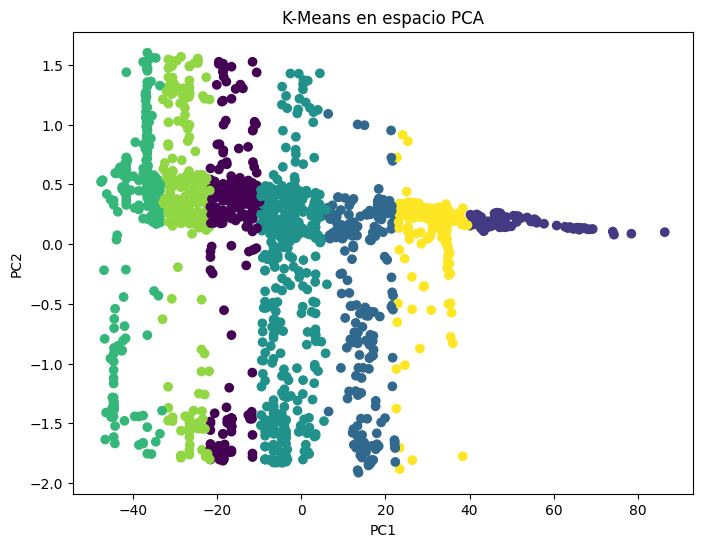

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_kmeans)
plt.title("K-Means en espacio PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

4. Ahora, entrene el modelo de agrupamiento aglomerativo con el set de datos de dos dimensiones. Grafique los resultados según altura y peso de las estimaciones y obtenga su evaluación. Compare estos resultados con los del inciso 2.

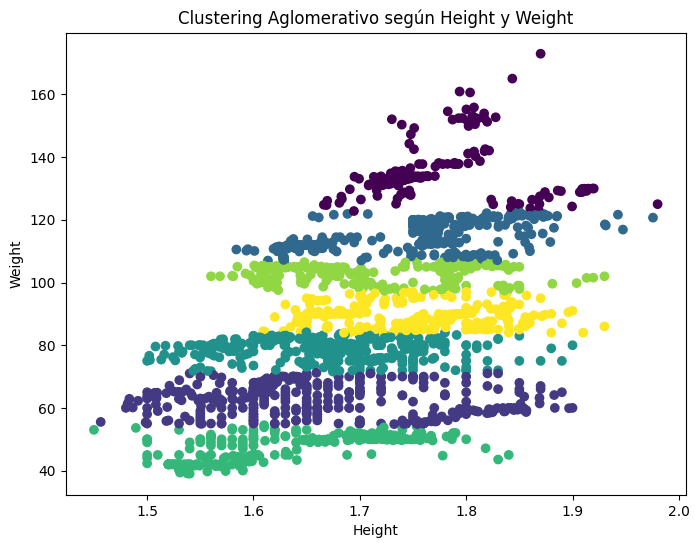

Silhouette K-Means: 0.5136003470647296
Silhouette Agglomerative: 0.5055666688626369


In [4]:
from sklearn.cluster import AgglomerativeClustering

ac = AgglomerativeClustering(n_clusters=7, linkage='ward')
y_ac = ac.fit_predict(X_pca)

plt.figure(figsize=(8,6))
plt.scatter(df["Height"], df["Weight"], c=y_ac)
plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Clustering Aglomerativo según Height y Weight")
plt.show()

silhouette_ac = silhouette_score(X, y_ac)
silhouette_ac

print("Silhouette K-Means:", silhouette_kmeans)
print("Silhouette Agglomerative:", silhouette_ac)